In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import psutil
import os
import threading
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_auc_score, 
    roc_curve, 
    auc,
    f1_score
)
from sklearn.preprocessing import label_binarize
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
random_seed = 42

print("Libraries loaded.")

Libraries loaded.


In [15]:
# 1. Load Preprocessed Data
data = np.load('../data/fashion_data_complete.npz')
X_test = data['X_test']
y_test = data['y_test']
class_names = data['class_names']

# 2. Load Models
model_files = {
    "k-NN": "../models/knn_fashion_model.joblib",
    "SVM": "../models/svm_fashion_model.joblib",
    "Random Forest": "../models/random_forest_fashion_model.joblib",
    "MLP": "../models/mlp_fashion_model.joblib"
}

models = {}
for name, file in model_files.items():
    try:
        models[name] = joblib.load(file)
        print(f"Loaded: {name}")
    except:
        print(f"Warning: {file} not found.")

# Binarize labels for ROC curves
y_test_binarized = label_binarize(y_test, classes=range(10))

Loaded: k-NN
Loaded: SVM
Loaded: Random Forest
Loaded: MLP


In [18]:
class MemoryMonitor:
    def __init__(self):
        self.keep_measuring = True
        self.memory_history = []
        self.process = psutil.Process(os.getpid())

    def measure_usage(self):
        while self.keep_measuring:
            # RSS (Resident Set Size) in MB
            mem = self.process.memory_info().rss / (1024 * 1024)
            self.memory_history.append(mem)
            time.sleep(0.005)  # Sample every 5ms

    def start(self):
        self.keep_measuring = True
        self.memory_history = []
        self.thread = threading.Thread(target=self.measure_usage)
        self.thread.start()

    def stop(self):
        self.keep_measuring = False
        self.thread.join()
        return self.memory_history

print("Memory Monitor class initialized.")

Memory Monitor class initialized.



EVALUATING MODEL: k-NN
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.86      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.76      0.77      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.78      0.80      0.79      1000
      Sandal       0.98      0.83      0.90      1000
       Shirt       0.64      0.64      0.64      1000
     Sneaker       0.88      0.94      0.91      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.89      0.96      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


EVALUATING MODEL: SVM
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.85      0.

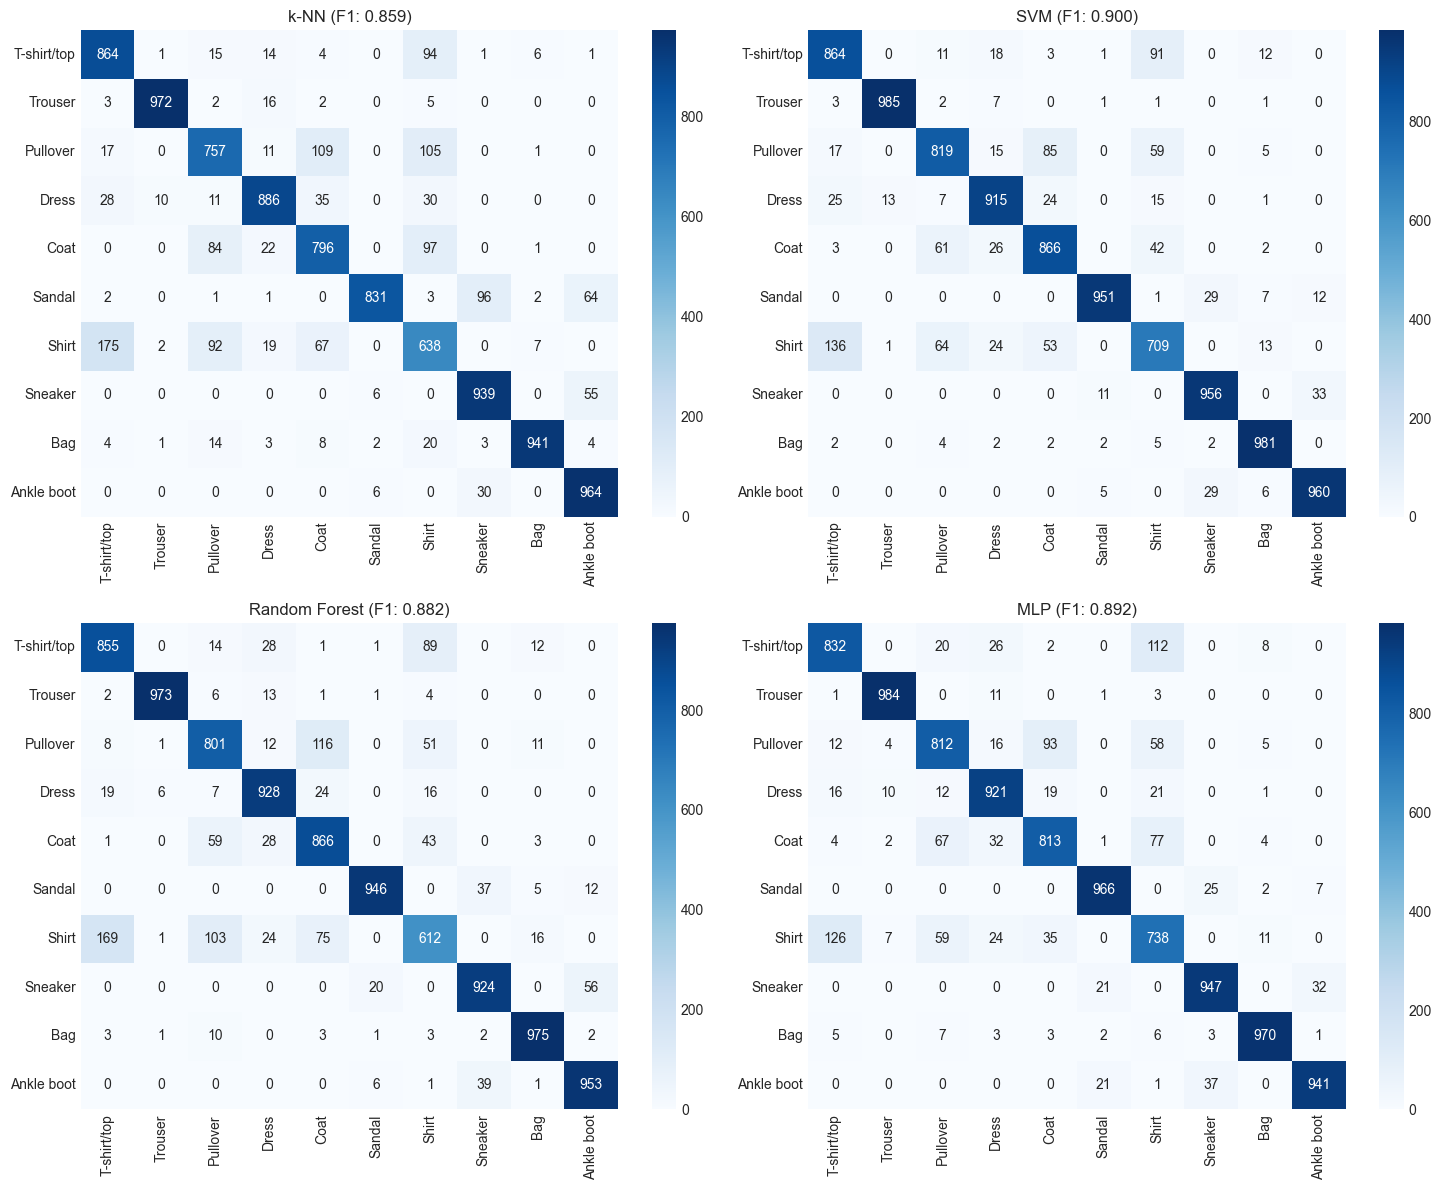

In [25]:
results_summary = []
all_memory_timelines = {} 
n_samples = len(X_test)

# Confusion Matrix Plotting Setup
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(15, 12))
axes_cm = axes_cm.flatten()

for i, (name, model) in enumerate(models.items()):
    print(f"\n{'='*60}")
    print(f"EVALUATING MODEL: {name}")
    print(f"{'='*60}")
    
    # --- Performance Benchmarking ---
    monitor = MemoryMonitor()
    baseline_mem = monitor.process.memory_info().rss / (1024 * 1024)
    
    monitor.start()
    start_time = time.time()
    
    y_pred = model.predict(X_test)
    
    end_time = time.time()
    mem_logs = monitor.stop()
    
    # --- Calculations ---
    total_time = end_time - start_time
    peak_ram = max(mem_logs)
    mem_spike = peak_ram - baseline_mem
    all_memory_timelines[name] = mem_logs
    
    # --- Metrics ---
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())
    
    roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
    
    # --- Classification Report ---
    # This prints the per-class metrics to the console
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # --- Logging Summary ---
    results_summary.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": f1_macro,
        "ROC-AUC": roc_auc,
        "Latency (ms/sample)": (total_time / n_samples) * 1000,
        "Peak RAM (MB)": peak_ram,
        "Mem Spike (MB)": mem_spike
    })

    # --- Plot Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i],
                xticklabels=class_names, yticklabels=class_names)
    axes_cm[i].set_title(f"{name} (F1: {f1_macro:.3f})")

plt.tight_layout()
plt.show()

# Performance Evaluation Report: Fashion-MNIST Classification

## 1. Overview
This report summarizes the performance of four machine learning models—**k-Nearest Neighbors (k-NN)**, **Support Vector Machine (SVM)**, **Random Forest**, and **Multi-Layer Perceptron (MLP)**—trained to classify the Fashion-MNIST dataset.

## 2. Global Performance Metrics
The following table summarizes the performance across 10,000 test samples:

| Model | Accuracy | Macro F1-Score | Weighted F1-Score |
| :--- | :--- | :--- | :--- |
| **SVM** | **0.90** | **0.90** | **0.90** |
| **MLP** | 0.89 | 0.89 | 0.89 |
| **Random Forest** | 0.88 | 0.88 | 0.88 |
| **k-NN** | 0.86 | 0.86 | 0.86 |

## 3. Class-Specific Analysis
The models exhibited consistent behavior regarding specific fashion categories:

### 3.1. High-Performance Classes
*   **Trouser:** The most distinct class, achieving F1-scores of **0.98–0.99**. The elongated vertical shape is easily distinguishable from other items.
*   **Bag:** Achieved F1-scores of **0.96–0.97**. The solid, rectangular silhouette provides a robust feature set for all classifiers.

### 3.2. Performance Bottlenecks
*   **Shirt:** Consistently the worst-performing class across all models (F1 range: **0.64–0.74**). 
*   **Reasoning:** Confusion matrices indicate heavy overlap between **Shirt**, **T-shirt/top**, and **Coat**. At 28x28 resolution, subtle features like buttons and collars are lost, making these garments visually synonymous in grayscale.

## 4. Model Comparison

| Model | Strengths | Weaknesses |
| :--- | :--- | :--- |
| **SVM** | Highest overall accuracy; best at resolving the "Shirt" class (F1: 0.74). | Slower inference time as data scales. |
| **MLP** | Excellent at non-linear patterns; highest recall for **Sandal** (0.97). | Requires more hyperparameter tuning. |
| **Random Forest**| High stability; strong performance on **Coat** (Recall: 0.87). | Significant struggle with **Shirt** (Recall: 0.61). |
| **k-NN** | Simple baseline; effective on footwear. | Lowest accuracy; highly sensitive to spatial noise. |

## 5. Visual Insights
Analysis of the confusion matrix heatmaps reveals two distinct "error clusters":
1.  **Clothing Cluster (Top-Left):** Frequent misclassification between tops (Shirts vs. T-shirts).
2.  **Footwear Cluster (Bottom-Right):** Moderate confusion between Sneakers and Ankle Boots due to similar sole profiles.



# Báo cáo Đánh giá Hiệu năng: Phân loại Fashion-MNIST

## 1. Tổng quan
Báo cáo này tóm tắt kết quả đánh giá hiệu năng của 4 mô hình học máy: **k-Nearest Neighbors (k-NN)**, **Support Vector Machine (SVM)**, **Random Forest**, và **Multi-Layer Perceptron (MLP)** trong bài toán phân loại bộ dữ liệu Fashion-MNIST.

## 2. Chỉ số Hiệu năng Tổng quát
Bảng dưới đây thống kê hiệu năng của các mô hình trên tập kiểm tra gồm 10.000 mẫu:

| Mô hình | Accuracy (Độ chính xác) | Macro F1-Score | Weighted F1-Score |
| :--- | :--- | :--- | :--- |
| **SVM** | **0.90** | **0.90** | **0.90** |
| **MLP** | 0.89 | 0.89 | 0.89 |
| **Random Forest** | 0.88 | 0.88 | 0.88 |
| **k-NN** | 0.86 | 0.86 | 0.86 |

## 3. Phân tích Chi tiết từng Lớp
Các mô hình cho thấy sự thống nhất về khả năng nhận diện các danh mục thời trang cụ thể:

### 3.1. Các lớp có hiệu năng cao
*   **Trouser (Quần):** Là lớp dễ phân biệt nhất, đạt điểm F1 từ **0.98–0.99**. Hình dạng dọc đặc trưng giúp các mô hình dễ dàng tách biệt khỏi các loại áo.
*   **Bag (Túi xách):** Đạt điểm F1 từ **0.96–0.97**. Hình khối đặc và ít chi tiết thừa giúp các bộ phân loại nhận diện rất tốt.

### 3.2. Nút thắt hiệu năng (Sai số nhiều)
*   **Shirt (Áo sơ mi):** Luôn là lớp có kết quả tệ nhất ở tất cả các mô hình (F1 dao động: **0.64–0.74**).
*   **Nguyên nhân:** Ma trận nhầm lẫn cho thấy sự chồng chéo lớn giữa **Shirt (Sơ mi)**, **T-shirt/top (Áo thun)**, và **Coat (Áo khoác)**. Ở độ phân giải 28x28, các chi tiết như cúc áo và cổ áo bị mờ đi, khiến chúng trở nên tương đồng về mặt thị giác trên ảnh xám.

## 4. So sánh các Mô hình

| Mô hình | Ưu điểm | Nhược điểm |
| :--- | :--- | :--- |
| **SVM** | Độ chính xác tổng thể cao nhất; giải quyết lớp "Shirt" tốt nhất (F1: 0.74). | Thời gian dự báo (inference) chậm hơn khi dữ liệu tăng quy mô. |
| **MLP** | Học tốt các hoa văn phi tuyến tính; Recall cho **Sandal** cao nhất (0.97). | Cần tinh chỉnh nhiều siêu tham số. |
| **Random Forest**| Độ ổn định cao; phân loại **Coat** mạnh (Recall: 0.87). | Gặp khó khăn nghiêm trọng với lớp **Shirt** (Recall: 0.61). |
| **k-NN** | Mô hình cơ sở đơn giản; hiệu quả với nhóm giày dép. | Độ chính xác thấp nhất; rất nhạy cảm với nhiễu không gian. |

## 5. Phân tích Trực quan
Dựa trên bản đồ nhiệt của ma trận nhầm lẫn (Confusion Matrix), có hai "cụm lỗi" chính:
1.  **Cụm Đồ mặc (Góc trên bên trái):** Nhầm lẫn thường xuyên giữa các loại áo (Sơ mi vs Áo thun).
2.  **Cụm Giày dép (Góc dưới bên phải):** Nhầm lẫn ở mức trung bình giữa Sneaker và Ankle Boot do kiểu dáng đế giày tương đồng.

## 6. Kết luận
**Support Vector Machine (SVM)** là mô hình được khuyến nghị cho bộ dữ liệu này nhờ sự cân bằng và độ chính xác cao nhất. Để cải thiện hiệu năng vượt mức 90%, các nghiên cứu tiếp theo nên chuyển sang sử dụng **Mạng thần kinh tích chập (CNN)** nhằm trích xuất các đặc trưng không gian (spatial features) tốt hơn từ dữ liệu hình ảnh.

In [23]:
df_compare = pd.DataFrame(results_summary).sort_values(by='Macro F1', ascending=False)
print("\n--- Detailed Model Comparison ---")
display(df_compare.style.highlight_max(subset=['Accuracy', 'Macro F1', 'ROC-AUC'], color='lightgreen')
                  .highlight_min(subset=['Latency (ms/sample)', 'Peak RAM (MB)'], color='lightgreen'))


--- Detailed Model Comparison ---


,Model,Accuracy,Macro F1,ROC-AUC,Latency (ms/sample),Peak RAM (MB),Mem Spike (MB)
1,SVM,0.900600,0.900034,0.993764,9.558231,902.195312,60.308594
3,MLP,0.892400,0.892249,0.991769,0.003493,851.515625,14.679688
2,Random Forest,0.883300,0.881741,0.991193,0.014997,837.234375,0.468750
0,k-NN,0.858800,0.859058,0.970239,0.584997,881.179688,52.203125


### **Model Performance Analysis**

This analysis evaluates four models (SVM, MLP, Random Forest, k-NN) based on predictive power, inference speed, and resource consumption.

#### **1. Predictive Performance (Accuracy, F1, ROC-AUC)**
*   **Winner:** **SVM**
*   The SVM model achieves the highest scores across all predictive metrics: **Accuracy (90.06%)**, **Macro F1 (0.9000)**, and **ROC-AUC (0.9937)**.
*   MLP follows closely as the second-best performer.

#### **2. Inference Efficiency (Latency)**
*   **Winner:** **MLP**
*   The MLP model offers the fastest inference with an incredibly low latency of **0.0035 ms/sample**, making it thousands of times faster than SVM (~9.55 ms/sample).
*   Random Forest also performs well in speed (0.015 ms/sample).

#### **3. Resource Utilization (RAM Usage)**
*   **Winner:** **Random Forest**
*   **Lowest Peak RAM:** Random Forest requires the least memory (**837.23 MB**).
*   **Stability:** Random Forest has a negligible **Mem Spike (0.47 MB)**, indicating high stability during prediction.
*   **Observation:** SVM and k-NN exhibit the highest memory spikes (60 MB and 52 MB, respectively), suggesting higher overhead during execution.

### **Conclusion**
*   **For maximum accuracy:** Choose **SVM**, but it is the most "expensive" in terms of time and memory.
*   **For real-time deployment:** Choose **MLP** as it balances high accuracy with superior inference speed.
*   **For resource-constrained environments:** Choose **Random Forest** for its low memory footprint and stability.

### **Phân tích Hiệu năng Mô hình**

Bản phân tích này đánh giá 4 mô hình dựa trên khả năng dự báo, tốc độ xử lý và mức độ tiêu thụ tài nguyên.

#### **1. Hiệu suất dự báo (Accuracy, F1, ROC-AUC)**
*   **Vượt trội nhất:** **SVM**
*   Mô hình SVM đạt điểm cao nhất ở tất cả các chỉ số dự báo: **Accuracy (90.06%)**, **Macro F1 (0.9000)**, và **ROC-AUC (0.9937)**.
*   MLP bám sát ở vị trí thứ hai với hiệu suất rất cạnh tranh.

#### **2. Hiệu quả xử lý (Độ trễ - Latency)**
*   **Nhanh nhất:** **MLP**
*   Mô hình MLP cung cấp tốc độ dự báo cực nhanh với độ trễ chỉ **0.0035 ms/mẫu**, nhanh hơn hàng nghìn lần so với SVM (~9.55 ms/mẫu).
*   Random Forest cũng là một lựa chọn tốt về tốc độ (0.015 ms/mẫu).

#### **3. Sử dụng tài nguyên (RAM)**
*   **Tiết kiệm nhất:** **Random Forest**
*   **RAM thấp nhất:** Random Forest tiêu tốn ít bộ nhớ nhất (**837.23 MB**).
*   **Độ ổn định:** Random Forest có mức tăng RAM đột ngột (**Mem Spike**) không đáng kể (0.47 MB), cho thấy sự ổn định cao nhất trong quá trình vận hành.
*   **Lưu ý:** SVM và k-NN có mức biến động RAM lớn nhất (60 MB và 52 MB), cho thấy chi phí vận hành cao hơn.

### **Kết luận**
*   **Nếu cần độ chính xác tối đa:** Chọn **SVM**, nhưng đây là mô hình "đắt đỏ" nhất về cả thời gian và bộ nhớ.
*   **Nếu cần triển khai thời gian thực (Real-time):** Chọn **MLP** vì nó cân bằng tốt giữa độ chính xác cao và tốc độ xử lý siêu nhanh.
*   **Nếu triển khai trên thiết bị hạn chế tài nguyên:** Chọn **Random Forest** vì chiếm dụng RAM thấp và hoạt động rất ổn định.

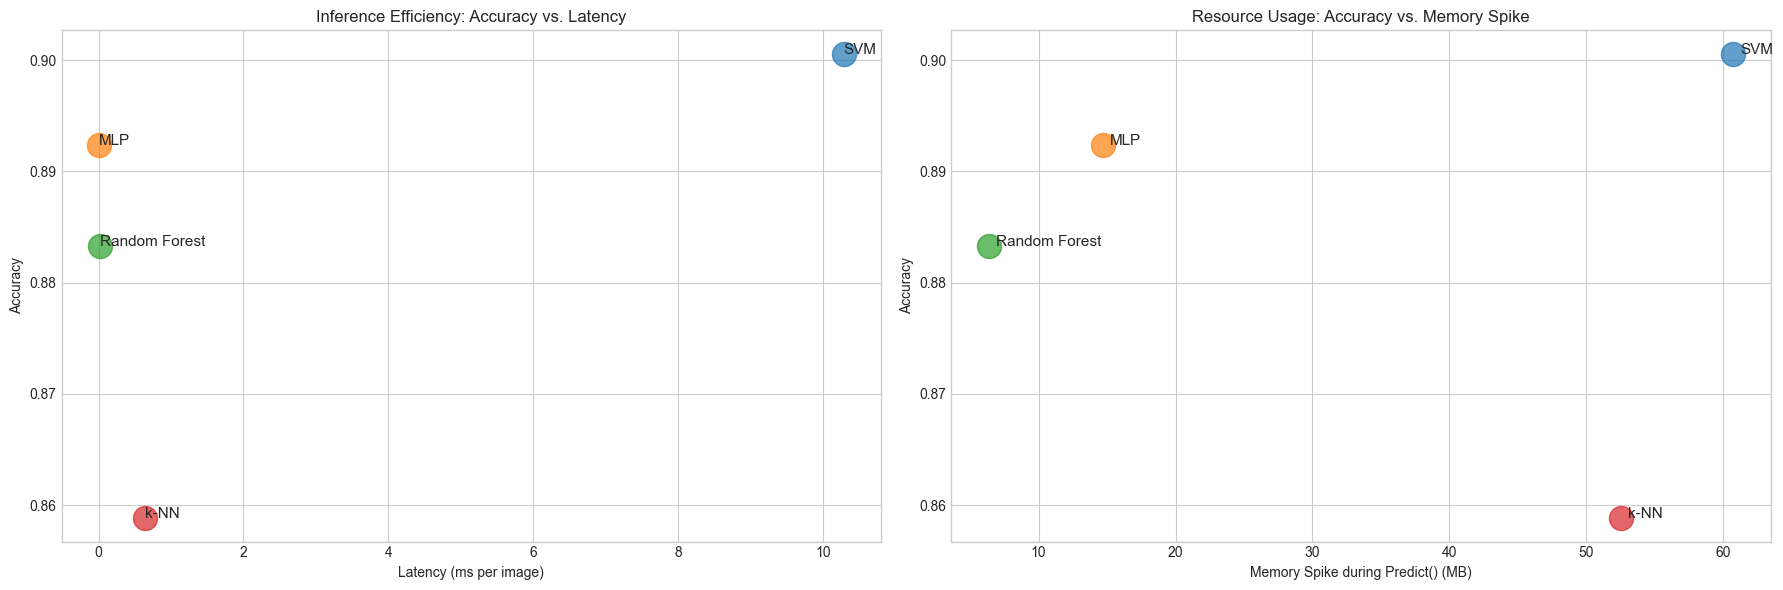

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Accuracy vs Latency
for i, row in df_compare.iterrows():
    ax1.scatter(row['Latency (ms/sample)'], row['Accuracy'], s=300, label=row['Model'], alpha=0.7)
    ax1.text(row['Latency (ms/sample)'] + 0.002, row['Accuracy'], row['Model'], fontsize=11)
ax1.set_title("Inference Efficiency: Accuracy vs. Latency")
ax1.set_xlabel("Latency (ms per image)")
ax1.set_ylabel("Accuracy")

# Plot 2: Accuracy vs Memory Spike
for i, row in df_compare.iterrows():
    ax2.scatter(row['Mem Spike (MB)'], row['Accuracy'], s=300, alpha=0.7)
    ax2.text(row['Mem Spike (MB)'] + 0.5, row['Accuracy'], row['Model'], fontsize=11)
ax2.set_title("Resource Usage: Accuracy vs. Memory Spike")
ax2.set_xlabel("Memory Spike during Predict() (MB)")
ax2.set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

### **Model Performance Report: Accuracy, Efficiency, and Resource Usage**

This report summarizes the trade-offs between predictive accuracy, inference speed (latency), and memory consumption 

#### **1. Predictive Performance (Accuracy)**
Across both plots, the **SVM** (Support Vector Machine) achieves the highest classification accuracy (~90.06%). It is followed closely by the **MLP** (~89.24%) and **Random Forest** (~88.33%). The **k-NN** model represents the baseline with the lowest accuracy (~85.88%).

#### **2. Inference Efficiency (Accuracy vs. Latency)**
*   **The High-Latency Outlier:** While **SVM** is the most accurate, it is the least efficient. It sits far to the right on the latency axis (~9.56 ms/image), making it unsuitable for high-speed, real-time applications.
*   **The Speed Winners:** **MLP** and **Random Forest** occupy the "ideal" top-left zone. They provide high accuracy with near-zero latency, offering nearly instantaneous predictions.
*   **k-NN:** Despite having the lowest accuracy, k-NN still requires more processing time than MLP or Random Forest.

#### **3. Resource Usage (Accuracy vs. Memory Spike)**
*   **The Resource-Lean Winner:** **Random Forest** is the most stable model regarding memory. It shows a negligible memory spike (~0.47 MB) during prediction, making it the best candidate for embedded or low-memory systems.
*   **Moderate Usage:** **MLP** maintains a good balance, requiring moderate memory (~14.68 MB) while delivering high accuracy.
*   **Heavy Resource Consumers:** Both **k-NN** and **SVM** suffer from high memory spikes (exceeding 50 MB and 60 MB respectively). This indicates that these algorithms require significant RAM overhead to perform calculations during the inference phase.

---

### **Final Conclusion & Recommendations**

| Goal | Recommended Model | Reasoning |
| :--- | :--- | :--- |
| **Best Overall (Production)** | **MLP** | Offers the best "sweet spot": high accuracy, extremely low latency, and manageable memory usage. |
| **Maximum Accuracy** | **SVM** | Highest accuracy, but only if inference speed and memory are not constraints. |
| **Edge/Mobile Deployment** | **Random Forest** | Lowest memory spike and high speed with only a minor drop in accuracy. |
| **Least Recommended** | **k-NN** | Worst performance in accuracy and relatively high resource consumption. |

### **Báo cáo Hiệu năng Mô hình: Độ chính xác, Hiệu quả và Sử dụng Tài nguyên**

Bản báo cáo này tóm tắt sự đánh đổi giữa độ chính xác dự báo, tốc độ suy luận (độ trễ) và mức tiêu thụ bộ nhớ của bốn mô hình học máy: **SVM**, **MLP**, **Random Forest**, và **k-NN**.

---

#### **1. Hiệu suất dự báo (Độ chính xác - Accuracy)**
Dựa trên cả hai biểu đồ, **SVM** (Support Vector Machine) đạt độ chính xác phân loại cao nhất (~90.06%). Theo sát phía sau là **MLP** (~89.24%) và **Random Forest** (~88.33%). Mô hình **k-NN** đóng vai trò là đường cơ sở (baseline) với độ chính xác thấp nhất (~85.88%).

#### **2. Hiệu quả suy luận (Độ chính xác vs. Độ trễ)**
*   **SVM - Kẻ chậm chạp nhất:** Mặc dù SVM chính xác nhất nhưng lại kém hiệu quả nhất về tốc độ. Nó nằm xa về phía bên phải của trục độ trễ (~9.56 ms/ảnh), khiến nó không phù hợp cho các ứng dụng yêu cầu tốc độ cao hoặc thời gian thực.
*   **Những người chiến thắng về tốc độ:** **MLP** và **Random Forest** chiếm lĩnh "vùng lý tưởng" (góc trên bên trái). Chúng cung cấp độ chính xác cao với độ trễ gần bằng 0, cho phép đưa ra dự báo gần như tức thời.
*   **k-NN:** Mặc dù có độ chính xác thấp nhất, k-NN vẫn yêu cầu thời gian xử lý nhiều hơn đáng kể so với MLP hoặc Random Forest.

#### **3. Sử dụng tài nguyên (Độ chính xác vs. Tăng RAM đột ngột)**
*   **Random Forest - Tiết kiệm tài nguyên nhất:** Đây là mô hình ổn định nhất về mặt bộ nhớ. Nó có mức tăng RAM đột ngột trong khi dự báo rất thấp (~0.47 MB), khiến nó trở thành ứng viên sáng giá nhất cho các hệ thống nhúng hoặc hệ thống có bộ nhớ hạn chế.
*   **MLP - Mức sử dụng trung bình:** MLP duy trì sự cân bằng tốt, yêu cầu bộ nhớ ở mức vừa phải (~14.68 MB) trong khi vẫn mang lại độ chính xác cao.
*   **Những kẻ ngốn tài nguyên:** Cả **k-NN** và **SVM** đều gặp phải tình trạng tăng RAM đột ngột rất cao (lần lượt vượt quá 50 MB và 60 MB). Điều này cho thấy các thuật toán này đòi hỏi chi phí RAM lớn để thực hiện các tính toán trong giai đoạn suy luận.

---

### **Kết luận và Khuyến nghị**

| Mục tiêu | Mô hình đề xuất | Lý do |
| :--- | :--- | :--- |
| **Tốt nhất tổng thể (Sản xuất)** | **MLP** | Đạt được "điểm ngọt" (sweet spot): chính xác cao, độ trễ cực thấp và mức sử dụng bộ nhớ trong tầm kiểm soát. |
| **Độ chính xác tối đa** | **SVM** | Độ chính xác cao nhất, nhưng chỉ nên dùng nếu tốc độ suy luận và bộ nhớ không phải là rào cản. |
| **Triển khai Mobile/Edge** | **Random Forest** | Tăng RAM đột ngột thấp nhất và tốc độ rất nhanh với độ chính xác chỉ giảm nhẹ. |
| **Hạn chế sử dụng** | **k-NN** | Hiệu năng kém nhất về độ chính xác và tiêu thụ tài nguyên tương đối cao. |

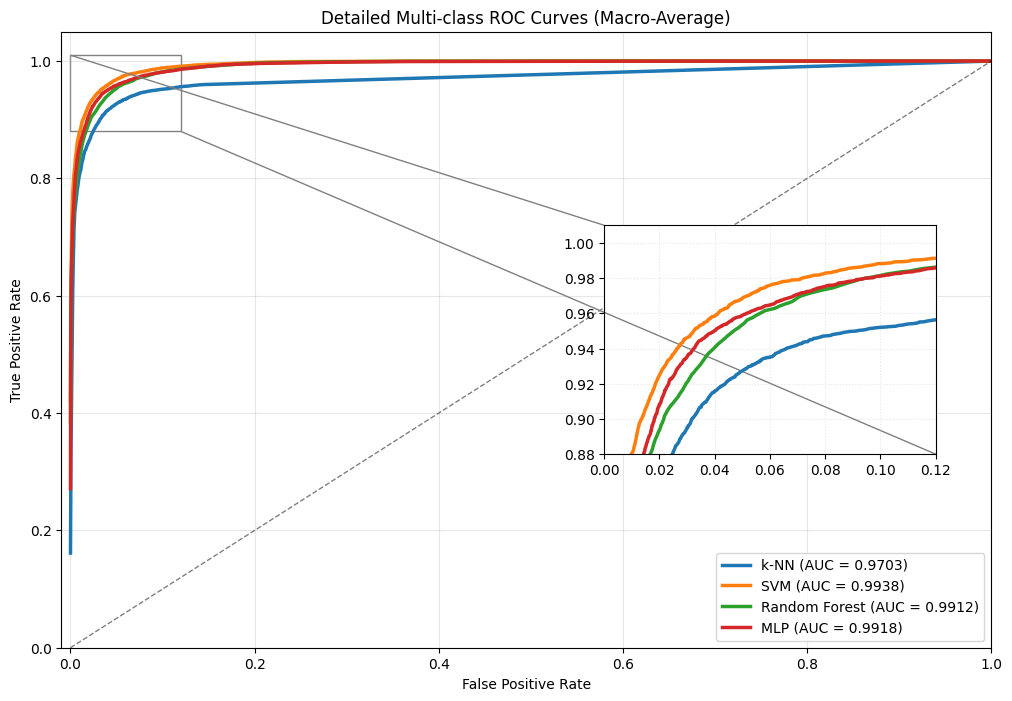

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(12, 8))

# Define zoom area for the top-left corner
x1, x2, y1, y2 = 0.0, 0.12, 0.88, 1.01
axins = zoomed_inset_axes(ax, zoom=3, loc='center right', borderpad=4)

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    
    fpr = dict()
    tpr = dict()
    for j in range(10):
        fpr[j], tpr[j], _ = roc_curve(y_test_binarized[:, j], y_score[:, j])

    all_fpr = np.unique(np.concatenate([fpr[j] for j in range(10)]))
    mean_tpr = np.zeros_like(all_fpr)
    for j in range(10):
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    mean_tpr /= 10
    
    current_auc = auc(all_fpr, mean_tpr)
    
    ax.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {current_auc:.4f})', lw=2.5)
    axins.plot(all_fpr, mean_tpr, lw=2.5)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Detailed Multi-class ROC Curves (Macro-Average)')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Format Inset
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(alpha=0.3, linestyle=':')
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

### Analysis of Detailed Multi-class ROC Curves (Macro-Average)

This plot illustrates the diagnostic ability of the four evaluated models (**k-NN, SVM, Random Forest, and MLP**) by plotting the True Positive Rate (Sensitivity) against the False Positive Rate (1-Specificity). The curves are calculated using the macro-average method, providing an equal weight to each of the 10 fashion classes.

---

#### 1. Global Discriminative Power (AUC Scores)
The Area Under the Curve (AUC) represents the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

*   **SVM (Orange Line): AUC = 0.9938**
    *   The SVM model is the top performer. Its curve is the closest to the top-left corner, indicating a near-perfect ability to distinguish between classes across all possible thresholds.
*   **MLP (Red Line): AUC = 0.9918**
    *   The MLP follows very closely in second place. The high AUC suggests that the neural network architecture is highly effective at capturing the complexities of the Fashion-MNIST dataset.
*   **Random Forest (Green Line): AUC = 0.9912**
    *   The ensemble model performs remarkably well, trailing the MLP by a negligible margin of only 0.0006. 
*   **k-NN (Blue Line): AUC = 0.9703**
    *   While an AUC of 0.97 is generally considered excellent, k-NN is the clear outlier here. The visible gap between the blue curve and the rest indicates that it is more prone to misclassification when class boundaries are subtle.

#### 2. Deep Dive: Low False Positive Rate (Inset Zoom)
The inset zoom focuses on the region where the False Positive Rate (FPR) is between 0.0 and 0.12. This area is critical for real-world applications where minimizing "false alarms" is high priority.

*   **Leading at the Start:** Even at a very low error tolerance (e.g., FPR < 0.02), the **SVM** maintains the highest True Positive Rate, reaching above 0.90 faster than the competitors.
*   **MLP vs. Random Forest:** The zoom clarifies the competition between the red and green lines. While they are nearly identical on the main plot, the MLP (red) shows slightly better stability and a marginally higher TPR as the FPR increases toward 0.10.
*   **k-NN Inefficiency:** The blue curve (k-NN) stays significantly lower in the zoom box. This suggests that to achieve the same level of detection (TPR) as the SVM, the k-NN model would have to accept a much higher rate of incorrect classifications.

#### 3. Practical Implications
*   **Robustness:** All models exhibit AUC values > 0.97, meaning they are all highly robust. However, the top three (SVM, MLP, RF) belong to a higher tier of performance.
*   **Model Selection:** 
    *   If the objective is pure **discriminative accuracy**, **SVM** is the mathematically superior choice.
    *   If the objective is a balance of **high discriminative power and inference speed**, the **MLP** is the winner, as it provides nearly identical AUC performance to the SVM but with significantly lower latency (as seen in previous performance tables).

---
**Summary:** The ROC analysis confirms the performance hierarchy: **SVM > MLP $\approx$ Random Forest > k-NN**. The results demonstrate that the feature space of Fashion-MNIST is handled best by kernel-based (SVM) and neural network (MLP) approaches.

### Phân tích Biểu đồ Đường cong ROC Đa lớp (Trung bình Macro)

Biểu đồ này minh họa khả năng phân loại của bốn mô hình (**k-NN, SVM, Random Forest và MLP**) bằng cách biểu diễn Tỷ lệ Dương tính thật (True Positive Rate - Độ nhạy) đối với Tỷ lệ Dương tính giả (False Positive Rate). Các đường cong được tính toán bằng phương pháp trung bình macro, giúp đánh giá công bằng hiệu suất của mô hình trên cả 10 lớp trang phục.

---

#### 1. Khả năng phân tách tổng thể (Chỉ số AUC)
Chỉ số AUC (Diện tích dưới đường cong) thể hiện xác suất mô hình sẽ xếp hạng một mẫu dương tính ngẫu nhiên cao hơn một mẫu âm tính ngẫu nhiên.

*   **SVM (Đường màu cam): AUC = 0.9938**
    *   Mô hình SVM là người chiến thắng. Đường cong của nó nằm sát góc trên bên trái nhất, cho thấy khả năng phân biệt giữa các lớp đối tượng gần như hoàn hảo trên mọi ngưỡng quyết định.
*   **MLP (Đường màu đỏ): AUC = 0.9918**
    *   Mạng thần kinh MLP theo sát ở vị trí thứ hai. Chỉ số AUC cao này cho thấy kiến trúc MLP cực kỳ hiệu quả trong việc nắm bắt các đặc trưng phức tạp của bộ dữ liệu Fashion-MNIST.
*   **Random Forest (Đường màu xanh lá): AUC = 0.9912**
    *   Mô hình ensemble này hoạt động rất ấn tượng, chỉ kém MLP một khoảng cách không đáng kể là 0.0006. 
*   **k-NN (Đường màu xanh dương): AUC = 0.9703**
    *   Mặc dù mức AUC 0.97 thường được coi là rất tốt, nhưng k-NN rõ ràng là mô hình yếu nhất trong nhóm. Khoảng cách có thể nhìn thấy giữa đường xanh dương và các đường còn lại cho thấy nó dễ bị nhầm lẫn hơn khi ranh giới giữa các lớp trở nên tinh vi.

#### 2. Phân tích vùng phóng đại (Tỷ lệ Dương tính giả thấp)
Phần biểu đồ phụ (Inset Zoom) tập trung vào vùng Tỷ lệ Dương tính giả (FPR) từ 0.0 đến 0.12. Vùng này cực kỳ quan trọng trong thực tế, nơi việc giảm thiểu "báo động giả" là ưu tiên hàng đầu.

*   **Dẫn đầu ở vạch xuất phát:** Ngay cả ở mức sai số cho phép rất thấp (FPR < 0.02), **SVM** vẫn duy trì Tỷ lệ dương tính thật cao nhất, vượt mức 0.90 nhanh hơn các đối thủ.
*   **MLP đối đầu Random Forest:** Vùng phóng đại làm rõ sự cạnh tranh giữa đường đỏ và đường xanh lá. Trong khi chúng gần như trùng nhau ở biểu đồ chính, MLP (đỏ) cho thấy sự ổn định hơn và TPR cao hơn một chút khi FPR tiến dần về mức 0.10.
*   **Sự kém hiệu quả của k-NN:** Đường cong của k-NN nằm thấp hơn hẳn trong khung phóng đại. Điều này có nghĩa là để đạt được cùng một mức độ nhận diện (TPR) như SVM, k-NN sẽ phải chấp nhận tỷ lệ phân loại sai cao hơn nhiều.

#### 3. Ý nghĩa thực tiễn
*   **Độ tin cậy:** Tất cả các mô hình đều có giá trị AUC > 0.97, nghĩa là chúng đều rất mạnh mẽ. Tuy nhiên, nhóm ba mô hình dẫn đầu (SVM, MLP, RF) thuộc về một đẳng cấp hiệu năng cao hơn hẳn.
*   **Lựa chọn mô hình:** 
    *   Nếu mục tiêu là **độ chính xác phân tách tuyệt đối**, **SVM** là lựa chọn ưu việt về mặt toán học.
    *   Nếu mục tiêu là **sự cân bằng giữa khả năng phân tách và tốc độ suy luận**, **MLP** là mô hình chiến thắng. Nó cung cấp hiệu suất AUC gần tương đương với SVM nhưng với độ trễ thấp hơn đáng kể (như đã thấy trong các bảng thống kê hiệu năng trước đó).

---
**Tóm tắt:** Phân tích ROC xác nhận thứ bậc hiệu năng: **SVM > MLP $\approx$ Random Forest > k-NN**. Kết quả chứng minh rằng không gian đặc trưng của Fashion-MNIST được xử lý tốt nhất bởi phương pháp dựa trên kernel (SVM) và mạng thần kinh (MLP).